# Assignment: Monte Carlo vs Temporal-Difference Learning

_Empirically and Theoretically compare Monte Carlo and Temporal-Difference learning methods for value estimation and control_

In [2]:
import gymnasium as gym
# from gymnasium.wrappers import RecordVideo, RecordEpisodeStatistics
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/hegemon/RL-Assignments/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Environment: CliffWalking

The game starts with the player at location `[3, 0]` of the `4x12` grid world with the goal located at `[3, 11]`. If the player reaches the goal, the episode ends.

A cliff runs along `[3, 1..10]`. If the player moves to a cliff location, it returns to the start location.

The player makes moves until they reach the goal.

**Episode Termination**
To make the episode finite, we will terminate the episode after 1000 steps if the player has not reached the goal.

|||
|---|---|
|Action Space| Discrete(4) |
| Observation Space| Discrete(48) |

## Observation Space
There are $3 \times 12 + 1$  possible states. The player cannot be at cliff nor at the goal, so we have $3 \times 12$ states for the player and 1 state for the start location.

### Starting State
The player starts at location `[3, 0]` which corresponds to state `36`

### Episode End
The episode ends when the player reaches the goal at location `[3, 11]` which corresponds to state `47`.

## Action Space
The player can take 4 actions:
- 0: Up
- 1: Right
- 2: Down
- 3: Left



In [3]:
MAX_EPISODES_STEPS = 1000
NUM_EPISODES = 1000

env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
spec = env.spec
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")
print(f"Max Episode Steps: {spec.max_episode_steps}")
env.close()

Observation Space: Discrete(48)
Action Space: Discrete(4)
Max Episode Steps: 1000


# Part-A: State-Value Prediction
Fix a Stochastic Policy $\pi$

## Policy to-be-evaluated
We will evaluate the following stochastic policy $\pi(s)$ $\forall s \in \mathcal{S}$:

1. Action 0 (Up): 0.35
2. Action 1 (Right): 0.35
3. Action 2 (Down): 0.15
4. Action 3 (Left): 0.15


In [4]:
def policy(observation):
    base_probs = np.array([0.35, 0.35, 0.15, 0.15], dtype=float)
    return base_probs

## First-Visit Monte Carlo Prediction

### Pseudocode
```python
Initialize V(s) arbitrarily, for all s ∈ S+
Initialize returns(s) = [] for all s ∈ S+
for each episode:
    Generate an episode following π: S0, A0, R1, S1, A1, R2, ..., ST-1, AT-1, RT
    G = 0
    for t = T-1, T-2, ..., 0:
        G = γG + Rt+1
        if St not in S0, S1, ..., St-1:
            Append G to returns(St)
            V(St) = average(returns(St))
return V
```

In [5]:
def first_visit_mc_prediction(env, policy, num_episodes, gamma=1.0, alpha=None, return_v_at_points=None):
    nS = env.observation_space.n
    V = np.zeros(nS)

    intermediate_Vs = []

    # If Alpha is None, we will use the average returns for each state
    returns_sum = np.zeros(nS)
    returns_count = np.zeros(nS)

    for episdoe_num in tqdm(range(num_episodes), desc="Running First-Visit MC Prediction"):
        # 1. Generate an episode
        episode = []
        state, info = env.reset()
        done = False
        
        while not done:
            action = np.random.choice(len(policy(state)), p=policy(state))
            next_state, reward, terminated, truncated, info = env.step(action)
            episode.append((state, reward))
            state = next_state
            done = terminated or truncated

        # 2. Process the episode (Backward)
        G = 0
        visited_in_episode = set()
        # Create a dictionary to store the first-visit return for each state
        first_visit_returns = {}

        for t in reversed(range(len(episode))):
            s_t, r_t = episode[t]
            G = gamma * G + r_t

            first_visit_returns[s_t] = G

        # 3. Update global tracking only for visited states
        for s, return_val in first_visit_returns.items():
            if alpha is None:
                returns_sum[s] += return_val
                returns_count[s] += 1
                V[s] = returns_sum[s] / returns_count[s]
            else:
                V[s] += alpha * (return_val - V[s])  # Incremental update

        if return_v_at_points and (episdoe_num + 1) in return_v_at_points:
            intermediate_Vs.append(V.copy())

    return (V, intermediate_Vs) if return_v_at_points else V

In [66]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
first_visit_mc_values = first_visit_mc_prediction(env, policy, num_episodes=NUM_EPISODES)
env.close()

Running First-Visit MC Prediction:   0%|          | 0/1000 [00:00<?, ?it/s]

Running First-Visit MC Prediction: 100%|██████████| 1000/1000 [00:09<00:00, 101.19it/s]


In [46]:
print("State-Value Function (MC):")
print("The Values of the Cliff States (States 36-46) is 0. That's ok because they are uninhabitable.")
print("Smallest Value:", np.max(first_visit_mc_values[:-11]))
print("Value of State 35 (The State that should have best value because it's right above the terminal state): ", first_visit_mc_values[35])

State-Value Function (MC):
The Values of the Cliff States (States 36-46) is 0. That's ok because they are uninhabitable.
Smallest Value: -230.9307721952011
Value of State 35 (The State that should have best value because it's right above the terminal state):  -230.9307721952011


## TD(0) Prediction

### Pseudocode
```python
Initialize V(s) arbitrarily, for all s ∈ S+
for each episode:
    Initialize S
    for each step of episode:
        Take action A, observe R, S'
        V(S) = V(S) + α[R + γV(S') - V(S)]
        S = S'
return V
```

In [6]:
def td_zero_prediction(env, policy, num_episodes, alpha=0.1, gamma=1.0, return_v_at_points=None):
    nS = env.observation_space.n
    V = np.zeros(nS)

    intermediate_Vs = []

    for episode_num in tqdm(range(num_episodes), desc="Running TD(0) Prediction"):
        state, info = env.reset()
        done = False

        while not done:
            action = np.random.choice(len(policy(state)), p=policy(state))
            
            next_state, reward, terminated, truncated, info = env.step(action)
            
            # The Critical Update Logic
            # Only zero out the future value if we hit the actual Goal (terminated)
            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * V[next_state]
            
            V[state] += alpha * (td_target - V[state])

            state = next_state
            done = terminated or truncated

        if return_v_at_points and (episode_num + 1) in return_v_at_points:
            intermediate_Vs.append(V.copy())

    return (V, intermediate_Vs) if return_v_at_points else V

In [48]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
td_zero_values = td_zero_prediction(env, policy, num_episodes=NUM_EPISODES, alpha=0.1, gamma=1)
env.close()

Running TD(0) Prediction:   0%|          | 0/1000 [00:00<?, ?it/s]

Running TD(0) Prediction: 100%|██████████| 1000/1000 [00:09<00:00, 106.21it/s]


In [39]:
print("State-Value Function (TD(0)):")
print("The Values of the Cliff States (States 36-46) is 0. That's ok because they are uninhabitable.")
print("Smallest Value:", np.max(td_zero_values[:-11]))
print("Value of State 35 (The State that should have best value because it's right above the terminal state): ", td_zero_values[35])

State-Value Function (TD(0)):
The Values of the Cliff States (States 36-46) is 0. That's ok because they are uninhabitable.
Smallest Value: -331.3979217243775
Value of State 35 (The State that should have best value because it's right above the terminal state):  -331.3979217243775


## GT-Construction
#### **_Using Iterative Policy Evaluation_**

Since I have a model of the environment (deterministic transitions/rewards), I can construct a GT state-value function for the same fixed stochastic policy using iterative policy evaluation.

$V_{t+1}(s) = \sum_a \pi(a|s) \sum_{s',r} p(s',r|s,a) [r + \gamma V_t(s')]$


### Pseudocode


```python
Initialize V(s) arbitrarily, for all s ∈ S+

Repeat until convergence:
    Δ = 0
    for each s ∈ S:
        v = V(s)
        V(s) = sum_a π(a|s) * sum_{s',r} p(s',r|s,a) * [r + γV(s')]
        Δ = max(Δ, |v - V(s)|)
    if Δ < θ:  # θ is a small positive number
        break
return V
```



In [7]:

def iterative_policy_evaluation(env, policy_func, gamma=1.0, theta=1e-6):
    nS = env.observation_space.n
    nA = env.action_space.n
    P = env.unwrapped.P

    # Initialize V to 0. Target state (47) will remain 0 throughout.
    V = np.zeros(nS)

    while True:
        delta = 0
        V_new = np.copy(V)

        for s in range(nS):
            # Skip the target state; its value is always 0
            if s > 36 and s <= 47: 
                continue
                
            v_temp = 0
            probs = policy_func(s) # Returns [0.35, 0.35, 0.15, 0.15]
            
            for a in range(nA):
                action_prob = probs[a]
                for trans_prob, next_state, reward, done in P[s][a]:
                    v_temp += action_prob * trans_prob * (reward + gamma * V[next_state] * (not done))

            delta = max(delta, np.abs(v_temp - V[s]))
            V_new[s] = v_temp
        
        V = V_new
        if delta < theta:
            break

    return V

In [8]:

V = iterative_policy_evaluation(env, policy)
print("State-Value Function (Iterative Policy Evaluation):")
print("Smallest Value:", np.max(V[:-11]))
print("Value of State 35 (The State that should have best value because it's right above the terminal state): ", V[35])

State-Value Function (Iterative Policy Evaluation):
Smallest Value: -401.7441745148276
Value of State 35 (The State that should have best value because it's right above the terminal state):  -401.7441745148276


## Tasks
1. Run both algorithms for multiple episodes.
2. Plot Learning Curves: MSE vs Episodes
3. Compare Convergence Speed.
4. Study Sensitivity to $\alpha$

### Task 1
#### Already Done Above

### Task 2
#### Plot Learning Curves: MSE vs Episodes

In [67]:

episode_points = [1, 5, 10, 50, 100, 200, 300, 400, 600, 800, 1000, 2000, 3000, 4000, 6000, 8000, 10000]
alpha = 0.1

env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
constant_alpha_mc_values, constant_mc_intermediate_Vs = first_visit_mc_prediction(env, policy, num_episodes=10000, gamma=1.0, alpha=alpha, return_v_at_points=episode_points)
env.close()

env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
mc_values, mc_intermediate_Vs = first_visit_mc_prediction(env, policy, num_episodes=10000, gamma=1.0, alpha=None, return_v_at_points=episode_points)
env.close()

env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
td_values, td_intermediate_Vs = td_zero_prediction(env, policy, num_episodes=10000, alpha=alpha, gamma=1.0, return_v_at_points=episode_points)
env.close()

# MSE Calculation
mse_mc = [np.mean((V - v_intermediate) ** 2) for v_intermediate in mc_intermediate_Vs]
mse_constant_alpha_mc = [np.mean((V - v_intermediate) ** 2) for v_intermediate in constant_mc_intermediate_Vs]
mse_td = [np.mean((V - v_intermediate) ** 2) for v_intermediate in td_intermediate_Vs]



Running TD(0) Prediction: 100%|██████████| 10000/10000 [01:34<00:00, 105.84it/s]


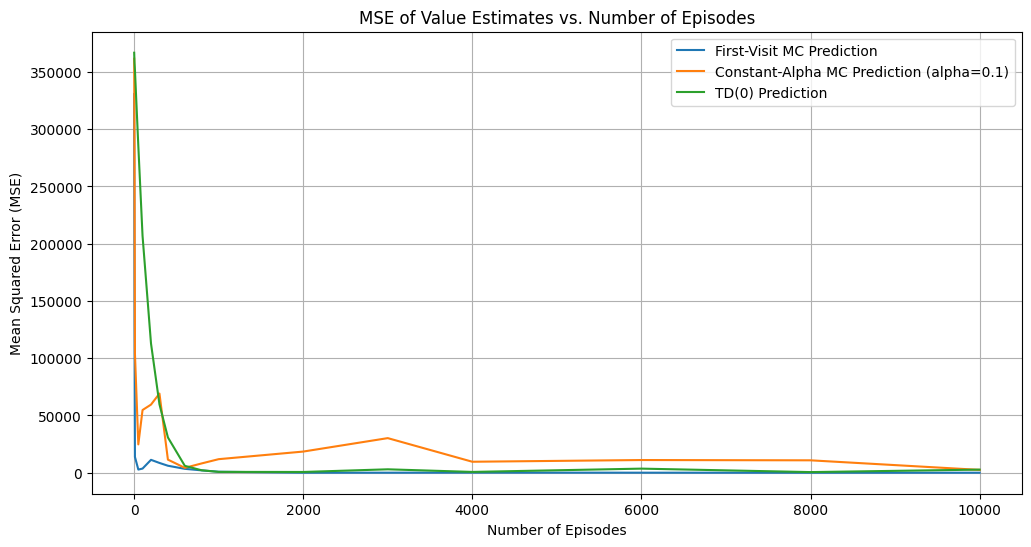

In [70]:
plt.figure(figsize=(12, 6))
plt.plot(episode_points, mse_mc, label='First-Visit MC Prediction')
plt.plot(episode_points, mse_constant_alpha_mc, label=f'Constant-Alpha MC Prediction (alpha={alpha})', )
plt.plot(episode_points, mse_td, label='TD(0) Prediction')

plt.xlabel('Number of Episodes')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE of Value Estimates vs. Number of Episodes')
plt.grid()
plt.legend()
plt.show()

![](mse_vs_episodes.png)

### Task 3
#### Compare Convergence Speed

Theoretically, "which algorithm converges faster" is an open question and no one has been able to prove mathematically that one method converges faster than the other. However, in practice, TD(0) often converges faster than Constant-alpha Monte Carlo prediction. TD(0) updates its estimates after every step, allowing it to learn from incomplete episodes and propagate value information more quickly. In contrast, Monte Carlo prediction only updates its estimates at the end of each episode, which can lead to slower convergence.

This observation can also be seen in the preceeding graph where TD(0) converged at around episode-1000 whilst Constant-alpha Monte Carlo prediction converged at around episode-10000. Even if, First-Visit Monte Carlo prediction converged faster than Constant-alpha Monte Carlo prediction, it didn't converge faster than parameter-dependent TD(0) prediction, as can been seen in the above graphs.

### Task 4
#### Study Sensitivity to Learning Rate $\alpha$

**For Both TD(0) and Constant-Alpha MC Prediction**

In [ ]:
alphas = [0.01, 0.1, 0.2, 0.5, 0.9]
episode_points_ = [1, 5, 10, 50, 100, 200, 300, 400, 600, 800, 1000, 2000]

env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)

alpha_results = {}

for alpha in alphas:
    mc_values, mc_intermediate_Vs = first_visit_mc_prediction(env, policy, num_episodes=max(episode_points_), gamma=1.0, alpha=alpha, return_v_at_points=episode_points_)
    td_values, td_intermediate_Vs = td_zero_prediction(env, policy, num_episodes=max(episode_points_), alpha=alpha, gamma=1.0, return_v_at_points=episode_points_)

    mse_mc = [np.mean((V - v_intermediate) ** 2) for v_intermediate in mc_intermediate_Vs]
    mse_td = [np.mean((V - v_intermediate) ** 2) for v_intermediate in td_intermediate_Vs]

    alpha_results[alpha] = {
        'mc': mse_mc,
        'td': mse_td
    }

env.close()


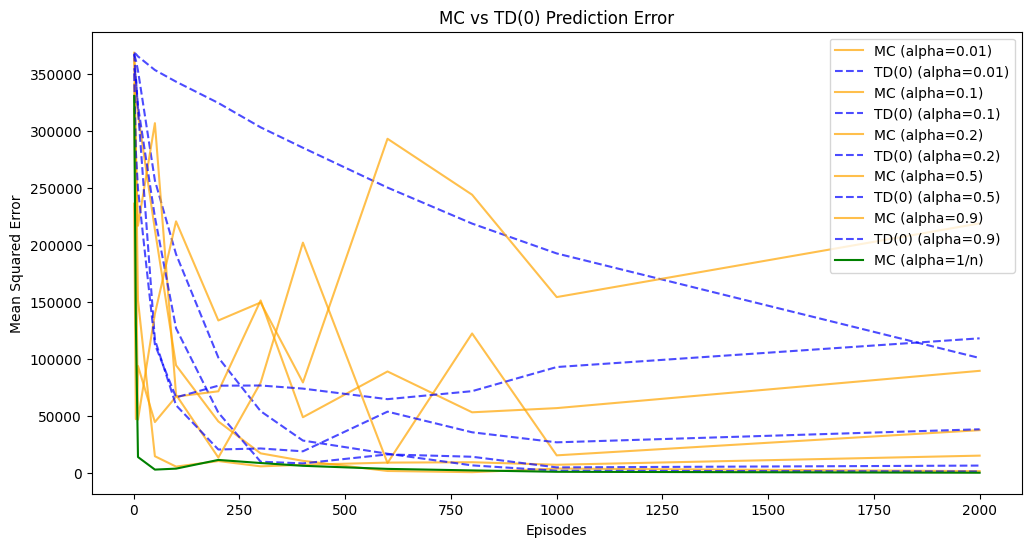

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
for alpha in alphas:
    plt.plot(episode_points_, alpha_results[alpha]['mc'], label=f'MC (alpha={alpha})', color='orange', alpha=0.7)
    plt.plot(episode_points_, alpha_results[alpha]['td'], label=f'TD(0) (alpha={alpha})', color='blue', alpha=0.7, linestyle='--')

plt.plot(episode_points_, mse_mc[:12], label=f'MC (alpha=1/n)', color='green')

plt.xlabel('Episodes')
plt.ylabel('Mean Squared Error')
plt.title('MC vs TD(0) Prediction Error')
plt.legend()
plt.show()


## Questions

#### Which method exhibits higher variance?

In [50]:
num_runs = 20
alpha = 0.5
episode_points_ = [1, 5, 10, 50, 100, 200]
# episode_points_ = [1, 5, 10]


env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)

mc_runs = []
td_runs = []

for i in range(num_runs):
    mc_values, mc_intermediate_Vs = first_visit_mc_prediction(env, policy, num_episodes=max(episode_points_), gamma=1.0, alpha=alpha, return_v_at_points=episode_points_)
    td_values, td_intermediate_Vs = td_zero_prediction(env, policy, num_episodes=max(episode_points_), alpha=alpha, gamma=1.0, return_v_at_points=episode_points_)

    mse_mc = [np.mean((V - v_intermediate) ** 2) for v_intermediate in mc_intermediate_Vs]
    mse_td = [np.mean((V - v_intermediate) ** 2) for v_intermediate in td_intermediate_Vs]

    mc_runs.append(mse_mc)
    td_runs.append(mse_td)

env.close()

# Plotting
# plt.figure(figsize=(12, 6))

Running TD(0) Prediction: 100%|██████████| 200/200 [00:02<00:00, 91.18it/s] 


In [57]:
mc_runs_np = np.array(mc_runs)
td_runs_np = np.array(td_runs)

print(mc_runs_np.shape, td_runs_np.shape)

(20, 6) (20, 6)


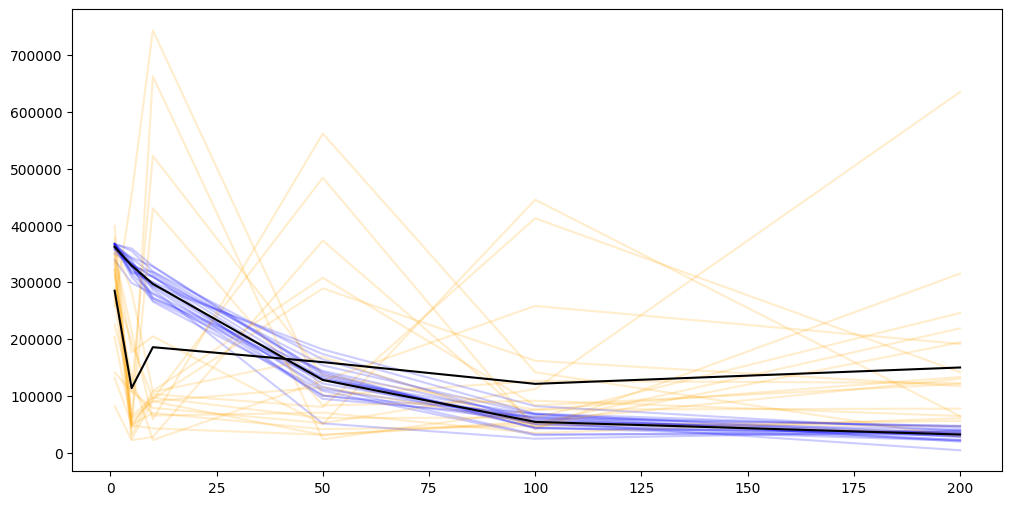

In [58]:
# Plotting
plt.figure(figsize=(12, 6))
for i in range(num_runs):
    plt.plot(episode_points_, mc_runs_np[i], label=f'MC (alpha={alpha})', color='orange', alpha=0.2)
    plt.plot(episode_points_, td_runs_np[i], label=f'TD(0) (alpha={alpha})', color='blue', alpha=0.2)

plt.plot(episode_points_, np.mean(mc_runs_np, axis=0), label=f'MC-Mean', color='black')
plt.plot(episode_points_, np.mean(td_runs_np, axis=0), label=f'TD-Mean', color='black')


plt.show()


In [59]:
print("Is Variance of MC greater than TD?: ",np.var(mc_runs_np) > np.var(td_runs_np))

Is Variance of MC greater than TD?:  True


Clearly, Monte-Carlo methods, especially Constant-Alpha MC Prediction, exhibit higher variance compared to TD(0) Prediction. This is because Monte-Carlo methods update their value estimates based on the returns observed at the end of episodes, which can be highly variable

#### Which method learns faster in early training?

We are comparing TD(0) Prediction, and Constant-Alpha Monte Carlo Prediction. 

Actually it depends on the problem and how far off the initial estimates are:

As was seen in the **Driving Home** example (Example 6.1), TD(0) Prediction learns faster in early training compared to Monte Carlo prediction, especially when the episode hasn't completed yet. This is because TD(0) updates its estimates after every step, allowing it to learn from incomplete episodes and propagate value information more quickly. In contrast, Monte Carlo prediction only updates its estimates at the end of each episode, which can lead to slower learning.

![](learning_curve.png)

But, in the above graphs, for higher alpha values, due to the unbiased naturate of Monte-Carlo, Constant-Alpha Monte-Carlo learns faster. Therefore, the answer depends on how far off the initial estimates are and the nature of the problem

Example: The Green Line ($\alpha = 1/n$): This represents the cumulative sample average. In stationary environments, the sample average is mathematically the most efficient way to reduce error, which is why it plummetts to near-zero almost instantly.

#### Explain the observed behavior using the bias–variance tradeoff.

Monte Carlo methods are  unbiased because they update values based on the actual return $G_t$ from a complete episode. This makes the target an "honest" representation of the state's value, but it introduces extreme variance because $G_t$ is the cumulative result of every random action and state transition in a trajectory; a single "unlucky" event can wildly distort the update. 

In contrast, TD(0) introduces bias through bootstrapping. It updates its current estimate using its own estimate of the next state, $V(S_{t+1})$, which is inherently "wrong" during early training. However, because TD only considers a single step of randomness, it has significantly lower variance. The tradeoff observed in performance curves typically shows that while MC can occasionally leap toward the truth with a high learning rate $\alpha$, its noise often prevents it from settling, whereas TD’s biased but stable updates allow for more consistent and efficient convergence.

-------

# Part-B: Action-Value Control

## Monte-Carlo Control

**I'll implement the Monte-Carlo On-Policy Control algorithm with $\epsilon$-soft policies** and converge to the optimal policy $\pi_*$.

### Pseudocode
```python
Initialize Q(s, a) arbitrarily, for all s ∈ S, a ∈ A(s)
Initialize returns(s, a) = [] for all s ∈ S, a ∈ A(s)
for each episode:
    Generate an episode following π in ε-greedy fashion: S0, A0, R1, S1, A1, R2, ..., ST-1, AT-1, RT
    G = 0
    for t = T-1, T-2, ..., 0:
        G = γG + Rt+1
        Append G to returns(St, At)
        Q(St, At) = average(returns(St, At))

π* = argmax_a Q(s, a) for all s ∈ S
return Q*, π*
```

In [93]:
def monte_carlo_control_epsilon_greedy(env, num_episodes, gamma=1.0, epsilon=0.1, cumulative_rewards_tracking=False):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    N = np.zeros((env.observation_space.n, env.action_space.n))  # Count of (s, a) pairs

    cumulative_rewards = []  # To track cumulative rewards per episode

    # We'll represent the policy implicitly through Q to save memory/time
    
    for _ in tqdm(range(num_episodes), desc="Training"):
        # 1. Generate an episode using epsilon-greedy policy derived from Q

        state, info = env.reset()
        episode = []
        done = False
        total_reward = 0

        while not done:
            # Epsilon-greedy selection
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
            
            next_state, reward, terminated, truncated, info = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            done = terminated or truncated
            
            total_reward += reward

        if cumulative_rewards_tracking:
            cumulative_rewards.append(total_reward)

        # 2. Process the episode
        G = 0
        first_visited_returns = {}

        # Iterate backward to calculate returns
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = gamma * G + r
            first_visited_returns[(s, a)] = G

        # 3. Update Q-values for first-visit (s, a) pairs
        for (s, a), return_val in first_visited_returns.items():
            N[s, a] += 1
            Q[s, a] += (return_val - Q[s, a]) / N[s, a]
            # Policy is implicitly updated because we use argmax(Q) in the next episode

    optimal_policy = np.argmax(Q, axis=1)

    if cumulative_rewards_tracking:
        return Q, optimal_policy, cumulative_rewards
    
    return Q, optimal_policy

In [95]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)

optimal_Q, optimal_policy = monte_carlo_control_epsilon_greedy(env, num_episodes=NUM_EPISODES * 2, gamma=1.0, epsilon=0.14)

print("Optimal Policy (0=Up, 1=Right, 2=Down, 3=Left):")
action_mapping = {0: '↑', 1: '→', 2: '↓', 3: '←'}
policy_grid = np.array([action_mapping[a] for a in optimal_policy]).reshape((4, 12))
print("Optimal Policy Grid:")
print(policy_grid)
env.close()

Training: 100%|██████████| 2000/2000 [00:00<00:00, 2741.07it/s]

Optimal Policy (0=Up, 1=Right, 2=Down, 3=Left):
Optimal Policy Grid:
[['→' '→' '↓' '←' '→' '↓' '→' '→' '→' '↓' '→' '↓']
 ['↑' '↑' '→' '→' '→' '→' '↑' '↑' '↑' '→' '↓' '←']
 ['↑' '→' '←' '↓' '←' '→' '↑' '↓' '↑' '→' '→' '↓']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']]


In [86]:
# Record Video
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
env = gym.wrappers.RecordVideo(env, video_folder="MC-Control-ideos", episode_trigger=lambda x: x == 0)  # Record only the first episode

num_test_episodes = 1

for episode in range(num_test_episodes):
    state, info = env.reset()
    done = False
    
    while not done:
        action = optimal_policy[state]
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    
env.close()

<video controls>
  <source src="MC-Control-ideos/rl-video-episode-0.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

## SARSA 
_On-Policy TD-Control_

### Pseudocode
```python
Initialize Q(s, a) arbitrarily, for all s ∈ S, a ∈ A(s)
for each episode:
    Initialize S
    Choose A from S using policy derived from Q (e.g., ε-greedy)
    for each step of episode:
        Take action A, observe R, S'
        Choose A' from S' using policy derived from Q (e.g., ε-greedy)
        Q(S, A) = Q(S, A) + α[R + γQ(S', A') - Q(S, A)]
        S = S'
        A = A'
return Q, π
```

In [96]:
def sarsa_control_epsilon_greedy(env, num_episodes, gamma=1.0, alpha=0.1, epsilon=0.1, cumulative_rewards_tracking=False):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    N = np.zeros_like(Q)  # Count of (s, a) pairs
    cumulative_rewards = []  # To track cumulative rewards per episode
    
    for _ in tqdm(range(num_episodes), desc="Training SARSA"):
        state, info = env.reset()
        # Choose action using epsilon-greedy policy derived from Q
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        
        done = False
        total_reward = 0
        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            
            # Choose next action using epsilon-greedy policy derived from Q
            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax(Q[next_state])
            
            # Update Q(s, a) using the SARSA update rule
            Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])
            
            state = next_state
            action = next_action
        
        if cumulative_rewards_tracking:
            cumulative_rewards.append(total_reward)

    optimal_policy = np.argmax(Q, axis=1)

    if cumulative_rewards_tracking:
        return Q, optimal_policy, cumulative_rewards

    return Q, optimal_policy

In [97]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
optimal_Q_sarsa, optimal_policy_sarsa = sarsa_control_epsilon_greedy(env, num_episodes=NUM_EPISODES * 2, gamma=1.0, alpha=0.1, epsilon=0.2)

print("Optimal Policy (0=Up, 1=Right, 2=Down, 3=Left):")
action_mapping = {0: '↑', 1: '→', 2: '↓', 3: '←'}
policy_grid = np.array([action_mapping[a] for a in optimal_policy_sarsa]).reshape((4, 12))
print("Optimal Policy Grid:")
print(policy_grid)

env.close()


Training SARSA:   0%|          | 0/2000 [00:00<?, ?it/s]

Training SARSA: 100%|██████████| 2000/2000 [00:00<00:00, 3703.50it/s]

Optimal Policy (0=Up, 1=Right, 2=Down, 3=Left):
Optimal Policy Grid:
[['→' '→' '→' '→' '→' '→' '→' '→' '→' '→' '→' '↓']
 ['↑' '↑' '→' '→' '↑' '↑' '↑' '→' '→' '→' '→' '↓']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '→' '↓']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']]


In [90]:
# Record Video
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=MAX_EPISODES_STEPS)
env = gym.wrappers.RecordVideo(env, video_folder="SARSA-Control-Videos", episode_trigger=lambda x: x == 0)  # Record only the first episode

num_test_episodes = 1

for episode in range(num_test_episodes):
    state, info = env.reset()
    done = False
    
    while not done:
        action = optimal_policy_sarsa[state]
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    
env.close()

<video controls>
  <source src="SARSA-Control-Videos/rl-video-episode-0.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

## Tasks

1. Compare cumulative reward per episode
2. Visualize the learned policy
3. Compare stability and speed of convergence 

### Task 1: Compare cumulative reward per episode

In [98]:
optimal_Q_MC, optimal_policy_MC, cumulative_rewards_MC = monte_carlo_control_epsilon_greedy(env, num_episodes=NUM_EPISODES * 2, gamma=1.0, epsilon=0.15, cumulative_rewards_tracking=True)
optimal_Q_SARSA, optimal_policy_SARSA, cumulative_rewards_SARSA = sarsa_control_epsilon_greedy(env, num_episodes=NUM_EPISODES * 2, gamma=1.0, alpha=0.1, epsilon=0.2, cumulative_rewards_tracking=True)

Training SARSA: 100%|██████████| 2000/2000 [00:00<00:00, 3934.72it/s]


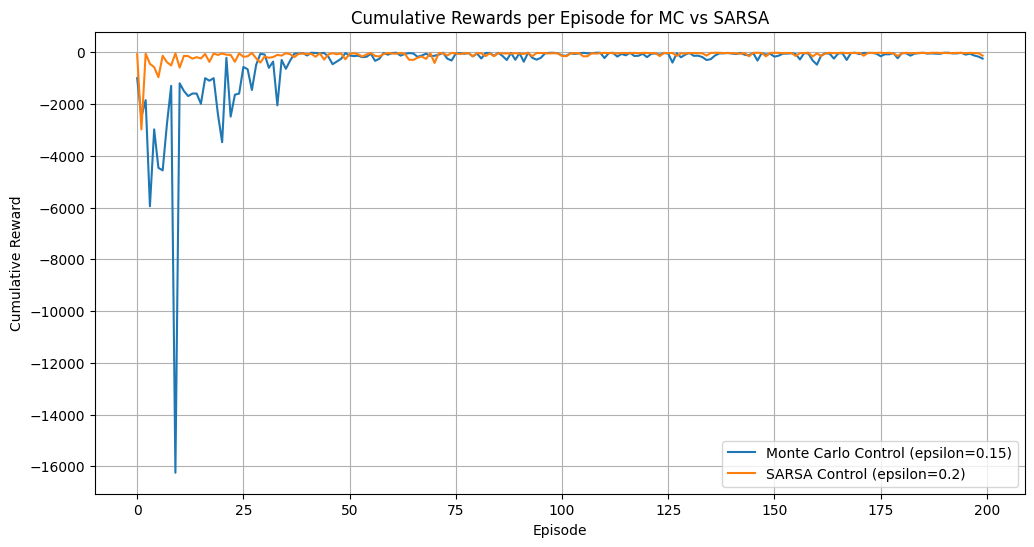

In [103]:
plt.figure(figsize=(12, 6))
plt.plot(cumulative_rewards_MC[:200], label='Monte Carlo Control (epsilon=0.15)')
plt.plot(cumulative_rewards_SARSA[:200], label='SARSA Control (epsilon=0.2)')
plt.yscale('linear')  # Use linear scale for better visibility of reward differences
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.title('Cumulative Rewards per Episode for MC vs SARSA')
plt.grid()
plt.legend()
plt.show()

### Task 2: Visualize the learned policy

#### SARSA Learned Policy

<video controls>
  <source src="SARSA-Control-Videos/rl-video-episode-0.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

#### Monte-Carlo Control Learned Policy

<video controls>
  <source src="MC-Control-ideos/rl-video-episode-0.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

### Task 3: Compare stability and speed of convergence

#### Stability

**Monte-Carlo**: 
The cumulative rewards per episode for Monte-Carlo Control show significant oscillations, especially in the early episodes. This is because Monte-Carlo methods update their action-value estimates based on the returns observed at the end of episodes, which can be highly variable. As a result, the learning process can be unstable, with large fluctuations in performance from one episode to the next.

**SARSA**: 
More Stable Learning Curve: The cumulative rewards per episode for SARSA Control show a more stable learning curve with fewer oscillations compared to Monte-Carlo Control. This is because SARSA updates its action-value estimates based on a single step of experience, which can lead to more stable estimates.

#### Speed of Convergence

**SARSA** wins over Monte-Carlo Control in terms of speed of convergence. 

## Questions

1. Why does Monte-Carlo require full-episodes?
2. Why can TD update online?
3. Which algorithm performs better in environments with high variance in returns?

### Why does Monte-Carlo require full-episodes?

Monte-Carlo methods require full episodes because they update their value estimates based on the returns observed at the end of episodes. The return is calculated as the total accumulated reward from the current state until the end of the episode. Therefore, Monte-Carlo methods need to wait until the episode is complete to calculate the return and update the value estimates.

### Why can TD update online?

Because they update their value estimates based on a single step of experience, rather than waiting for the end of an episode. This allows TD methods to learn and improve their estimates after every action taken.

### Which algorithm performs better in environments with high variance in returns?

TD methods, such as SARSA, generally perform better in environments with high variance in returns. This is because TD methods update their estimates based on a single step of experience, which can lead to more stable estimates even when the returns are highly variable. In contrast, Monte-Carlo methods can be more sensitive to high variance in returns since they rely on the total return observed at the end of episodes, which can fluctuate significantly.

The CliffWalking is an example of an environment with high variance in returns due to the presence of the cliff. If the agent falls off the cliff, it receives a large negative reward, which can lead to high variance in returns. In such environments, TD methods like SARSA can provide more stable learning and better performance compared to Monte-Carlo methods, as was proved in the above experiments.

-------

# Part-C: Theoretical Reflection
1. Show that TD(0) performs bootstrapping while Monte-Carlo does not.
2. Write the update equations for both methods and explain the key difference.
3. In what sense does TD approximate DP?

## 1. Show that TD(0) performs bootstrapping while Monte-Carlo does not.

The Update Equation for TD(0) is:

$$V(S) \leftarrow V(S) + \alpha [R + \gamma V(S') - V(S)]$$

Here, $R$ is received from the environment, which gives TD its Monte-Carlo-like property, and $V(S')$ is the estimate of the value of the next state, which gives TD its bootstrapping property.

The Update Equation for Monte-Carlo Prediction is:

$$V(S) \leftarrow V(S) + \alpha [G - V(S)]$$

Here, $G$ is the return observed at the end of the episode, which gives Monte-Carlo its non-bootstrapping property. Monte-Carlo methods do not use estimates of future values to update their current estimates, whereas TD methods do.

## 2. Write the update equations for both methods and explain the key difference.

The update equation for Monte-Carlo Prediction is:
$$V(S) \leftarrow V(S) + \alpha [G - V(S)]$$

Where $G$ is the return observed at the end of the episode.

The update equation for TD(0) Prediction is:
$$V(S) \leftarrow V(S) + \alpha [R + \gamma V(S') - V(S)]$$

The key difference between the two methods is that Monte-Carlo updates its value estimates based on the return observed at the end of episodes, which can be highly variable, while TD(0) updates its value estimates based on a single step of experience, which can lead to more stable estimates.

TD(0) can be considered a half-way between Monte-Carlo and Dynamic Programming (DP) because it uses bootstrapping like DP but samples from the environment like Monte-Carlo

## 3. In what sense does TD approximate DP?

TD methods approximate DP in the sense that they use bootstrapping to update their value estimates. In DP, we have a complete model of the environment and can compute the value function exactly using the Bellman equations. In contrast, TD methods do not require a model of the environment and instead learn from experience by updating their estimates based on the observed rewards and the estimated value of the next state. 

By using bootstrapping, TD methods can still converge to the optimal value function under certain conditions, effectively approximating the DP solution without needing a complete model of the environment.